## chapter3

#### example1

In [4]:
import torch
import numpy as np

t1 = torch.tensor(data=[10, 10], requires_grad=True, dtype=torch.float)
n1 = t1.detach().numpy()

print(f't1 = {t1}, n1 = {n1}\n')
print(f'addr: t1 = {id(t1)}, t2 = {id(n1)}')

t1 = tensor([10., 10.], requires_grad=True), n1 = [10. 10.]

addr: t1 = 2510041097856, t2 = 2510041189136


#### example2

In [11]:
import torch

x = torch.ones(3, 3)
print(f'input = {x}')
y = torch.zeros(3, 2)
print(f'target = {y}')

w = torch.randn(3, 2, requires_grad=True)
print(f'w = {w}')

b = torch.randn(2, requires_grad=True)
print(f'b = {b}')


z = torch.matmul(x, w) + b

c = torch.nn.MSELoss()
loss = c(z, y) 
loss.backward()

print(f'grad of w = {w.grad}')
print(f'grad of b = {b.grad}')

w.data -= 0.01 * w.grad
b.data -= 0.01 * b.grad

print(f'new w = {w.data}')
print(f'new b = {b.data}')




input = tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
target = tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])
w = tensor([[ 0.1255,  0.1470],
        [ 0.2707,  1.1577],
        [-0.0947, -1.0073]], requires_grad=True)
b = tensor([-1.6822,  0.0234], requires_grad=True)
grad of w = tensor([[-1.3807,  0.3209],
        [-1.3807,  0.3209],
        [-1.3807,  0.3209]])
grad of b = tensor([-1.3807,  0.3209])
new w = tensor([[ 0.1393,  0.1438],
        [ 0.2845,  1.1545],
        [-0.0809, -1.0105]])
new b = tensor([-1.6684,  0.0202])


#### example2: linear regression

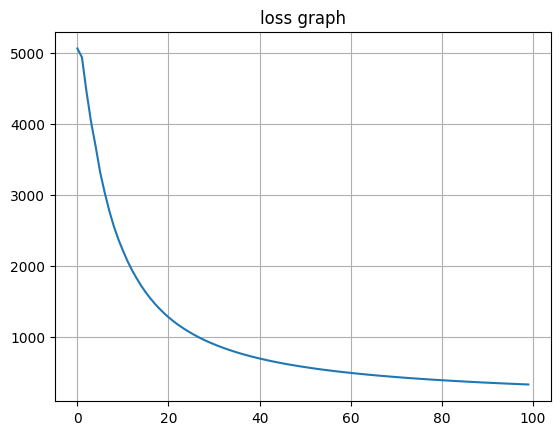

C:\Users\mzr\AppData\Local\Temp\ipykernel_10296\618762266.py:69: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  y_pred = torch.tensor(data= [x0 * train_w + train_b for x0 in x])
C:\Users\mzr\AppData\Local\Temp\ipykernel_10296\618762266.py:70: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_true = torch.tensor(data= [x0 * real_w + real_b for x0 in x])


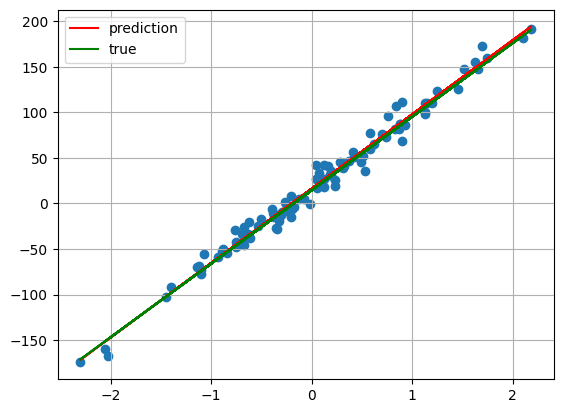

In [11]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import nn, optim
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

def create_dataset():
    x, y, coef = make_regression(
        n_samples= 100,
        n_features= 1,
        noise= 10,
        coef= True,
        bias= 14.5,
        random_state= 1
    )
    x = torch.tensor(x, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.float)

    return x, y, coef, 14.5


def train(x, y, coef):
    #1.数据集
    #2.数据加载器
    #3.创建模型
    #4.损失函数
    #5.优化器
    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, 16, shuffle=True)
    #训练集不打乱，测试集打乱
    model = nn.Linear(1, 1)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)


    #训练轮数
    epochs, loss_list, total_loss, total_sample = 100, [], 0.0, 0
    #分轮
    for i in range(epochs):
        #分批
        for train_x, train_y in loader:
            train_y = train_y.reshape(-1, 1)
            z = model(train_x)
            loss = criterion(z, train_y)
            total_loss += loss.item()
            total_sample += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        loss_list.append(total_loss / total_sample)
        #print(f'epochs = {i + 1}, avg_loss = {loss_list[i]}')
    
    #print(f'total_epochs = {epochs}, avg_loss = {loss_list}')
    train_w = model.weight
    train_b = model.bias
    return epochs, loss_list, train_w, train_b

def draw_loss(epochs, loss_list):
    plt.plot(range(epochs), loss_list)
    plt.title('loss graph')
    plt.grid()
    plt.show()
    pass

def draw_regression(x, y, train_w, train_b, real_w, real_b):
    plt.scatter(x, y)
    y_pred = torch.tensor(data= [x0 * train_w + train_b for x0 in x])
    y_true = torch.tensor(data= [x0 * real_w + real_b for x0 in x])
    plt.plot(x, y_pred, color= 'red', label= 'prediction')
    plt.plot(x, y_true, color= 'green', label= 'true')
    plt.legend()
    plt.grid()
    plt.show()
    pass


if __name__ == '__main__':
    x, y, coef, bias = create_dataset()
    epochs, loss_list, train_w, train_b = train(x, y, coef)
    draw_loss(epochs, loss_list)
    draw_regression(x, y, train_w, train_b, coef, bias)

#### example3: activate function

##### 1. application of activate function
- output layer:
    + dichotomy: sigmoid
    + multi-classification: softmax
    + regression: identity(y = x)
- hidden layer: (priority high -> low) ReLU, LeakyReLU, PReLU, tanh, sigmoid

##### 2. sigmoid
- input -> [0, 1]
- differencial -> [0, 0.25]
- while input > 6 or input < -6, output will approximately equals to 1 or 0
- output would be better when input is in [-3, 3]
- application: output layer of dichotomy
- *caution: gradient vanishment

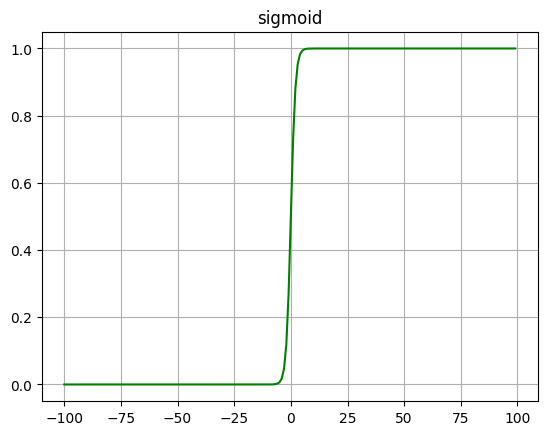

In [ ]:
import matplotlib.pyplot as plt
import torch
import math

plt.title('sigmoid')
x = torch.tensor(data=[x for x in range(-100, 100)])
y = torch.tensor(data= [1.0 / (1 + math.exp(-x)) for x in range(-100, 100)])
plt.plot(x, y, color='green')
plt.grid()
plt.show()

##### 3.tanh
- input -> [-1, 1]
- differencial -> [0, 1]
- while input > 3 or input < -3, output will approximately equals to 1 or -1
- application: hidden layer
- caution: gradient vanishment

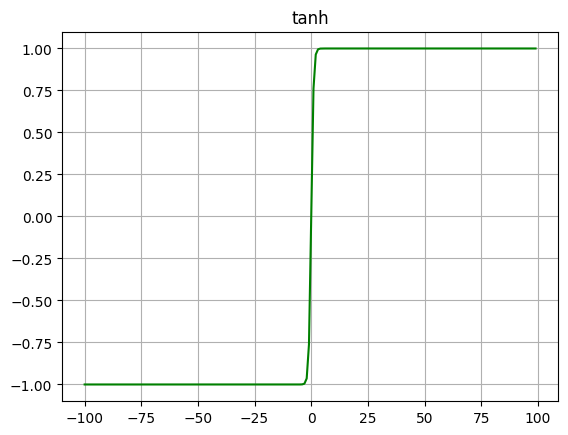

In [2]:
import matplotlib.pyplot as plt
import torch
import math

plt.title('tanh')
x = torch.tensor(data=[x for x in range(-100, 100)])
y = torch.tensor(data= [(1 - math.exp(-2 * x)) / (1 + math.exp(-2 * x)) for x in range(-100, 100)])
plt.plot(x, y, color='green')
plt.grid()
plt.show()

##### 4. ReLU
+ f(x) = max(0, x)
+ differencial: 0 or 1
+ focus on positive signal, an easier function (accelerate calculation)
+ relieve gradient vanishment but some negative weight coundn't be updated(neuron dead)
+ other ReLU:
    - Leaky ReLU: 0.01x in negative area
    - PReLU: kx in neg area (k could be updated)
    - swish: smooth ReLU ---- x * sigmoid(kx) (k could be updated)

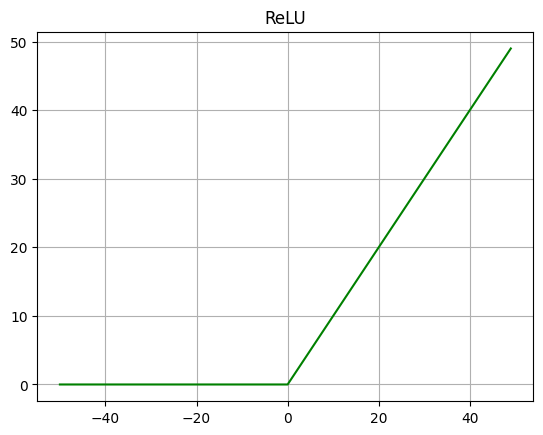

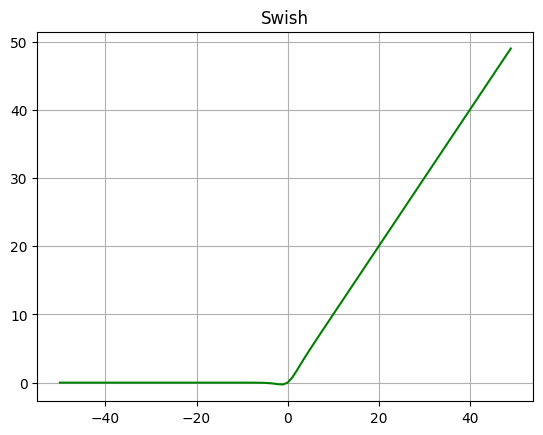

In [11]:
import matplotlib.pyplot as plt
import torch
import math

plt.title('ReLU')
x = torch.tensor(data=[x for x in range(-50, 50)])
y2 = torch.tensor(data= [x for x in range(0, 50)])
y1 = torch.zeros_like(y2)
y = torch.cat([y1, y2], 0)
plt.plot(x, y, color='green')
plt.grid()
plt.show()

plt.title('Swish')
x = torch.tensor(data=[x for x in range(-50, 50)])
y = torch.tensor(data= [x / (1 + math.exp(-x)) for x in range(-50, 50)])
plt.plot(x, y, color='green')
plt.grid()
plt.show()

##### 5. softmax
- input -> probability(sum = 1)
- application: output layer of multi-classification